In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
random_state = 42

In [35]:
df = pd.read_csv('data/balanced_dropout_dataset.csv')
print(df.shape)
df.head()

(4482, 18)


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Year of study,Department,Parental_Education,Dropout
0,19.2,0,25000.0,1,4.08,76.8,5,20.7,0,0,9.3,2.26,2.42,2.40,2,Engineering,Bachelor,1
1,21.3,1,36634.0,0,2.57,86.2,1,41.4,0,0,6.2,1.98,1.70,1.70,1,Engineering,High School,0
2,20.6,0,42980.0,1,2.94,78.9,4,45.8,0,0,6.2,1.65,1.53,1.56,4,Science,Bachelor,1
3,21.4,1,25000.0,1,4.94,75.5,1,51.4,1,1,5.3,2.18,2.20,2.20,1,Business,High School,1
4,21.5,1,97830.0,1,4.48,77.6,2,31.5,1,1,6.0,0.46,0.92,0.92,1,CS,High School,1


count    4482.000000
mean        5.792503
std         1.771336
min         1.000000
25%         4.600000
50%         5.800000
75%         7.000000
max        10.000000
Name: Stress_Index, dtype: float64


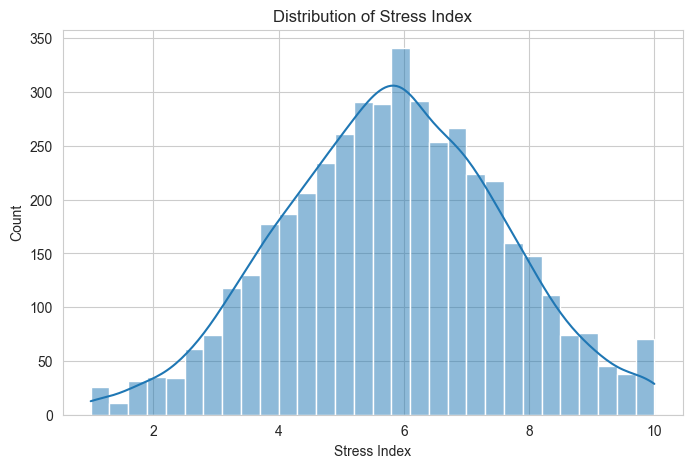

In [36]:
print(df['Stress_Index'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df['Stress_Index'], kde=True, bins=30)
plt.title('Distribution of Stress Index')
plt.xlabel('Stress Index')
plt.show()

In [37]:
df.corr(numeric_only=True)['Stress_Index'].sort_values(ascending=False)

Stress_Index             1.000000
Dropout                  0.297623
Assignment_Delay_Days    0.008702
Study_Hours_per_Day      0.005060
Part_Time_Job            0.003428
Gender                   0.000825
Year of study           -0.004164
Family_Income           -0.006375
Age                     -0.008825
Scholarship             -0.009271
Travel_Time_Minutes     -0.015716
Internet_Access         -0.019592
Attendance_Rate         -0.041739
CGPA                    -0.370311
Semester_GPA            -0.370391
GPA                     -0.389483
Name: Stress_Index, dtype: float64

In [38]:
selected_features = ['GPA', 'Semester_GPA', 'CGPA', 'Dropout']

X_reduced = df[selected_features]
y_reduced = df['Stress_Index']

X_reduced.head()

,GPA,Semester_GPA,CGPA,Dropout
0,2.26,2.42,2.40,1
1,1.98,1.70,1.70,0
2,1.65,1.53,1.56,1
3,2.18,2.20,2.20,1
4,0.46,0.92,0.92,1


In [39]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y_reduced, test_size=0.2, random_state=random_state
)

print(X_train_r.shape, X_test_r.shape)

(3585, 4) (897, 4)


In [40]:
stress_model_reduced = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_state=random_state,
    verbose=100
)

stress_model_reduced.fit(
    X_train_r, y_train_r,
    eval_set=(X_test_r, y_test_r)
)

0:	learn: 1.7647746	test: 1.7268686	best: 1.7268686 (0)	total: 4.57ms	remaining: 2.28s
100:	learn: 1.5989356	test: 1.6207290	best: 1.6176213 (58)	total: 270ms	remaining: 1.06s
200:	learn: 1.5698153	test: 1.6256902	best: 1.6176213 (58)	total: 536ms	remaining: 798ms
300:	learn: 1.5337590	test: 1.6343242	best: 1.6176213 (58)	total: 754ms	remaining: 499ms
400:	learn: 1.5001950	test: 1.6420303	best: 1.6176213 (58)	total: 976ms	remaining: 241ms
499:	learn: 1.4703797	test: 1.6498210	best: 1.6176213 (58)	total: 1.18s	remaining: 0us

bestTest = 1.617621304
bestIteration = 58

Shrink model to first 59 iterations.


CatBoostRegressor(depth=6, eval_metric='RMSE', iterations=500, learning_rate=0.05, loss_function='RMSE', random_state=42, verbose=100)

In [41]:
y_pred_r = stress_model_reduced.predict(X_test_r)

mae_r = mean_absolute_error(y_test_r, y_pred_r)
rmse_r = root_mean_squared_error(y_test_r, y_pred_r)
r2_r = r2_score(y_test_r, y_pred_r)

print("="*50)
print("REDUCED MODEL (GPA, Semester_GPA, CGPA, Dropout)")
print(f"MAE:  {mae_r:.4f}")
print(f"RMSE: {rmse_r:.4f}")
print(f"R²:   {r2_r:.4f}")
print("="*50)

REDUCED MODEL (GPA, Semester_GPA, CGPA, Dropout)
MAE:  1.3105
RMSE: 1.6176
R²:   0.1348
